# 20. How the self-similar exponents $\alpha,\beta$ shape the tSZ power spectrum

Fix the GNFW pressure **shape** to its default ($P_0,c_{500},\alpha_\mathrm{GNFW},
\beta_\mathrm{GNFW},\gamma$ from `GNFWPressureProfile`) and vary only the
**self-similar amplitude exponents** in

$$P_{500}=P_{500,0}\,(M_{500c}/M_\odot)^{\alpha}\,E(z)^{2+\beta},$$

where $\alpha$ is the mass slope and $\beta$ the $E(z)$ slope (nb17 convention;
self-similar $\alpha=\beta=2/3$). We plot the **shape** of the halo-model tSZ
$D_\ell$ — each curve normalized at $\ell=2000$, so the overall amplitude $P_{500,0}$
cancels and only the $\alpha/\beta$-driven change in the $\ell$-dependence remains.

In [1]:
import os
os.environ.setdefault("JAX_PLATFORMS", "cpu")
import sys
sys.path.insert(0, "/scratch/scratch-lxu/flamingo_repo/src")

import numpy as np
import matplotlib.pyplot as plt
import jax.numpy as jnp

from flamingo.catalogue import D3A_COSMOLOGY
from flamingo.profiles.custom_pressure import SelfSimilarGNFWPressureProfile
from hmfast.halos import HaloModel
from hmfast.tracers import tSZTracer

hm = HaloModel(cosmology=D3A_COSMOLOGY)
ell = jnp.logspace(1.3, np.log10(6000), 40)
m_grid = jnp.logspace(11.0, 15.5, 50)
z_grid = jnp.geomspace(0.01, 3.0, 50)
pref = np.asarray(ell) * (np.asarray(ell) + 1) / (2 * np.pi)
ell_np = np.asarray(ell)
ELL_REF = 2000.0   # normalization point for the shape comparison

def tsz_dl(alpha_amp, beta_amp):
    """Halo-model tSZ D_ell for fixed default GNFW shape and given amplitude slopes."""
    prof = SelfSimilarGNFWPressureProfile(P500_0=1.0, alpha_amp=alpha_amp, beta_amp=beta_amp)
    tr = tSZTracer(profile=prof)
    cl = np.asarray(hm.cl_1h(tr, tr, l=ell, m=m_grid, z=z_grid)) \
       + np.asarray(hm.cl_2h(tr, tr, l=ell, m=m_grid, z=z_grid))
    dl = pref * cl
    return dl / np.interp(ELL_REF, ell_np, dl)   # normalized at ELL_REF

In [2]:
ALPHAS = [0.40, 0.67, 1.00, 1.33, 1.67]   # mass slope (beta fixed)
BETAS = [-0.67, 0.00, 0.67, 1.33, 2.00]    # E(z) slope (alpha fixed)
BETA_FIX, ALPHA_FIX = 2.0 / 3.0, 2.0 / 3.0

dl_alpha = {a: tsz_dl(a, BETA_FIX) for a in ALPHAS}
dl_beta = {b: tsz_dl(ALPHA_FIX, b) for b in BETAS}
print("peak ell vs alpha:", {a: int(ell_np[np.argmax(d)]) for a, d in dl_alpha.items()})
print("peak ell vs beta :", {b: int(ell_np[np.argmax(d)]) for b, d in dl_beta.items()})

peak ell vs alpha: {0.4: 5999, 0.67: 4477, 1.0: 2494, 1.33: 1607, 1.67: 1200}
peak ell vs beta : {-0.67: 2494, 0.0: 2886, 0.67: 4477, 1.33: 5999, 2.0: 5999}


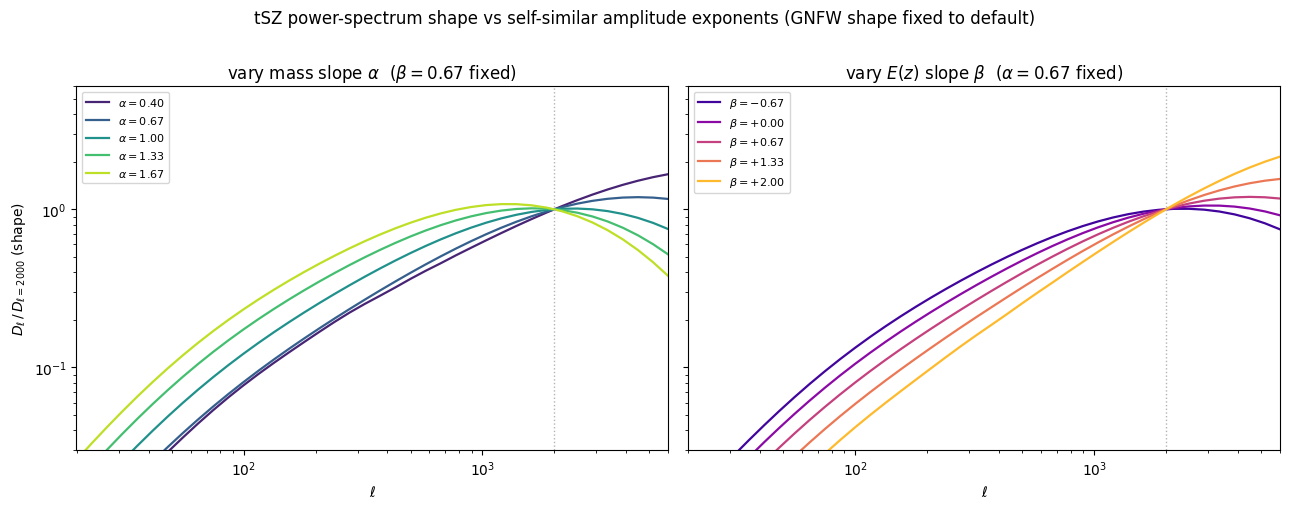

In [3]:
fig, (axA, axB) = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

cA = plt.cm.viridis(np.linspace(0.1, 0.9, len(ALPHAS)))
for col, a in zip(cA, ALPHAS):
    lw = 2.6 if abs(a - 2/3) < 1e-6 else 1.6
    axA.plot(ell_np, dl_alpha[a], color=col, lw=lw,
             label=fr"$\alpha={a:.2f}$" + (" (self-sim.)" if abs(a-2/3) < 1e-6 else ""))
axA.set_title(fr"vary mass slope $\alpha$  ($\beta={BETA_FIX:.2f}$ fixed)")
axA.set_xlabel(r"$\ell$"); axA.set_ylabel(r"$D_\ell\,/\,D_{\ell=2000}$ (shape)")

cB = plt.cm.plasma(np.linspace(0.1, 0.85, len(BETAS)))
for col, b in zip(cB, BETAS):
    lw = 2.6 if abs(b - 2/3) < 1e-6 else 1.6
    axB.plot(ell_np, dl_beta[b], color=col, lw=lw,
             label=fr"$\beta={b:+.2f}$" + (" (self-sim.)" if abs(b-2/3) < 1e-6 else ""))
axB.set_title(fr"vary $E(z)$ slope $\beta$  ($\alpha={ALPHA_FIX:.2f}$ fixed)")
axB.set_xlabel(r"$\ell$")

for ax in (axA, axB):
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.axvline(ELL_REF, color="0.7", ls=":", lw=1)
    ax.set_xlim(ell_np.min(), ell_np.max()); ax.set_ylim(3e-2, 6)
    ax.legend(fontsize=8)
fig.suptitle("tSZ power-spectrum shape vs self-similar amplitude exponents "
             "(GNFW shape fixed to default)", y=1.01)
fig.tight_layout(); plt.show()

### Trends

- **Mass slope $\alpha$** (left): increasing $\alpha$ up-weights the most massive
  halos, which subtend large angles, so power moves to **lower $\ell$** — the spectrum
  reddens and the peak shifts down (from $\ell\sim6000$ at $\alpha=0.4$ to
  $\ell\sim1300$ at $\alpha=1.67$).
- **$E(z)$ slope $\beta$** (right): increasing $\beta$ up-weights **high redshift**
  (where $E(z)$ is large), and high-$z$ clusters subtend smaller angles, so power moves
  to **higher $\ell$** — the peak shifts up.
- The two exponents therefore push the tSZ peak in **opposite** directions, and the
  overall amplitude (which scales as $P_{500,0}^2$ and the mean of $M^{2\alpha}$,
  $E^{2(2+\beta)}$) is separate from this shape — it is divided out here by
  normalizing each curve at $\ell=2000$.